In [26]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import seaborn as sns
from scipy import stats
from scipy.signal import find_peaks
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, HuberRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
import warnings
warnings.filterwarnings("ignore")

PROJECT_ROOT = Path.cwd().parent.parent
sys.path.insert(0, str(PROJECT_ROOT))

PROCESSED  = PROJECT_ROOT / "data" / "processed"
OUTPUT_DIR = Path.cwd() / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SEPHORA_COLOR   = "#E91E63"
ULTA_COLOR      = "#9C27B0"
RESILIENT_COLOR = "#4CAF50"
FRAGILE_COLOR   = "#F44336"
REPSEN_COLOR    = "#FF9800"
NEUTRAL         = "#90A4AE"

In [27]:
sephora_df = pd.read_csv(PROCESSED / "Sephora" / "sephora_segmentation.csv",
                          dtype={"product_id": str})
ulta_df    = pd.read_csv(PROCESSED / "Ulta"    / "ulta_segmentation.csv",
                          dtype={"product_id": str})
matched    = pd.read_csv(PROCESSED / "Matched" / "matched_pairs.csv",
                          dtype={"sephora_product_id": str,
                                 "ulta_product_id":    str})

# Load time-series review data if available (monthly aggregates per product)
# Expected columns: product_id, year_month, review_count, avg_rating, avg_sentiment
ts_paths = {
    "Sephora": PROCESSED / "Sephora" / "sephora_reviews_timeseries.csv",
    "Ulta":    PROCESSED / "Ulta"    / "ulta_reviews_timeseries.csv",
}
ts_data = {}
for platform, path in ts_paths.items():
    if path.exists():
        ts_data[platform] = pd.read_csv(path, dtype={"product_id": str})
        print(f"{platform} time-series: {len(ts_data[platform]):,} rows")
    else:
        print(f"{platform} time-series not found — simulating from snapshot features")

# Load cluster labels and join onto segmentation dataframes
s_clusters = pd.read_csv(PROCESSED / "Sephora" / "sephora_cluster_labels.csv",
                          dtype={"product_id": str})
u_clusters = pd.read_csv(PROCESSED / "Ulta"    / "ulta_cluster_labels.csv",
                          dtype={"product_id": str})

# Peek at column names in case they differ
print("Sephora cluster cols:", s_clusters.columns.tolist())
print("Ulta cluster cols:",    u_clusters.columns.tolist())

sephora_df = sephora_df.merge(s_clusters, on="product_id", how="left")
ulta_df    = ulta_df.merge(u_clusters,    on="product_id", how="left")

print("kmeans_weighted in sephora_df:", "kmeans_weighted" in sephora_df.columns)
print("kmeans_weighted in ulta_df:",    "kmeans_weighted" in ulta_df.columns)

Sephora time-series: 28,693 rows
Ulta time-series: 137,858 rows
Sephora cluster cols: ['product_id', 'bv_product_id', 'kmeans_weighted']
Ulta cluster cols: ['product_id', 'kmeans_weighted']
kmeans_weighted in sephora_df: True
kmeans_weighted in ulta_df: True


In [28]:
# From snapshot data, construct proxies for sensitivity dimensions:
#
# 1. Review velocity stability     — cv of review rate over time (or dispersion proxy)
# 2. Negative shock sensitivity    — how much pct_negative correlates with low velocity
# 3. Rating decline response       — rating_dispersion_over_time × pct_1_star (fragility)
# 4. Price deviation response      — price_vs_category_median × review velocity
# 5. Sentiment-velocity coupling   — partial corr: does sentiment drive velocity?

def build_sensitivity_features(df, platform):
    brand_col = "brand_normalized" if "brand_normalized" in df.columns else "brand"

    # Core columns needed — use what's available
    needed = ["product_id", brand_col, "price", "avg_rating", "avg_sentiment",
              "pct_positive", "pct_negative", "pct_1_star", "pct_5_star",
              "reviews_per_month", "review_count_normalized",
              "rating_std", "rating_dispersion_over_time",
              "price_vs_category_median", "kmeans_weighted"]
    cols = [c for c in needed if c in df.columns]
    feat = df[cols].copy().rename(columns={brand_col: "brand"})
    feat["platform"] = platform

    # ── Dimension 1: Price resilience
    # High price deviation from median + maintained velocity = price-resilient
    # High price deviation + suppressed velocity = price-sensitive
    if "price_vs_category_median" in feat.columns and \
       "reviews_per_month" in feat.columns:
        price_dev = feat["price_vs_category_median"].fillna(0)
        velocity  = feat["reviews_per_month"].fillna(0)
        # Normalise both to [0,1]
        price_dev_n = (price_dev - price_dev.min()) / \
                      (price_dev.max() - price_dev.min() + 1e-9)
        velocity_n  = (velocity  - velocity.min())  / \
                      (velocity.max()  - velocity.min()  + 1e-9)
        # Resilience: high velocity despite high price premium
        feat["price_resilience_score"] = velocity_n - price_dev_n
        # Fragility: velocity collapses when price is high
        feat["price_sensitivity_score"] = price_dev_n - velocity_n

    # ── Dimension 2: Reputation sensitivity
    # High pct_negative + low velocity = reputation-sensitive (bad reviews kill demand)
    # High pct_negative + maintained velocity = resilient (controversy drives engagement)
    if "pct_negative" in feat.columns and "reviews_per_month" in feat.columns:
        neg_n = (feat["pct_negative"] - feat["pct_negative"].min()) / \
                (feat["pct_negative"].max() - feat["pct_negative"].min() + 1e-9)
        vel_n = (feat["reviews_per_month"] - feat["reviews_per_month"].min()) / \
                (feat["reviews_per_month"].max() - feat["reviews_per_month"].min() + 1e-9)
        feat["reputation_sensitivity_score"] = neg_n * (1 - vel_n)
        feat["controversy_resilience_score"] = neg_n * vel_n

    # ── Dimension 3: Value fragility
    # Products where small rating declines predict large relative velocity drops
    # Proxied by: rating_std × pct_1_star (high variance + tail risk)
    if "rating_std" in feat.columns and "pct_1_star" in feat.columns:
        feat["value_fragility_score"] = feat["rating_std"] * feat["pct_1_star"]

    # ── Dimension 4: Sentiment-demand coupling
    # How tightly sentiment tracks velocity (high coupling = demand is sentiment-driven)
    if "avg_sentiment" in feat.columns and "reviews_per_month" in feat.columns:
        sent_n = (feat["avg_sentiment"] - feat["avg_sentiment"].min()) / \
                 (feat["avg_sentiment"].max() - feat["avg_sentiment"].min() + 1e-9)
        feat["sentiment_demand_coupling"] = sent_n * vel_n

    # ── Price tier
    if "price" in feat.columns:
        feat["price_tier"] = pd.cut(
            feat["price"],
            bins=[0, 20, 40, 75, 150, np.inf],
            labels=["<$20", "$20-40", "$40-75", "$75-150", "$150+"],
            right=True
        )

    return feat

s_feat = build_sensitivity_features(sephora_df, "Sephora")
u_feat = build_sensitivity_features(ulta_df,    "Ulta")
all_feat = pd.concat([s_feat, u_feat], ignore_index=True)

SENS_COLS = [c for c in ["price_resilience_score", "price_sensitivity_score",
                          "reputation_sensitivity_score", "controversy_resilience_score",
                          "value_fragility_score", "sentiment_demand_coupling"]
             if c in all_feat.columns]
print(f"Sensitivity dimensions built: {SENS_COLS}")
print(f"Total products: {len(all_feat):,}  "
      f"(Sephora: {(all_feat['platform']=='Sephora').sum():,}  "
      f"Ulta: {(all_feat['platform']=='Ulta').sum():,})")

Sensitivity dimensions built: ['price_resilience_score', 'price_sensitivity_score', 'reputation_sensitivity_score', 'controversy_resilience_score', 'value_fragility_score', 'sentiment_demand_coupling']
Total products: 12,859  (Sephora: 1,632  Ulta: 11,227)


In [29]:
# Three archetypes based on which sensitivity dimension dominates:
#   Price-Resilient:       high price_resilience, low reputation_sensitivity
#   Value-Fragile:         high value_fragility, high price_sensitivity
#   Reputation-Sensitive:  high reputation_sensitivity, low controversy_resilience

def classify_archetype(row):
    pr = row.get("price_resilience_score",    0) or 0
    ps = row.get("price_sensitivity_score",   0) or 0
    rs = row.get("reputation_sensitivity_score", 0) or 0
    vf = row.get("value_fragility_score",     0) or 0
    cr = row.get("controversy_resilience_score", 0) or 0

    scores = {
        "Price-Resilient":        pr - rs,
        "Value-Fragile":          vf + ps - pr,
        "Reputation-Sensitive":   rs - cr,
    }
    return max(scores, key=scores.get)

# Normalise sensitivity scores within platform before classifying
for platform in ["Sephora", "Ulta"]:
    mask = all_feat["platform"] == platform
    for col in SENS_COLS:
        if col in all_feat.columns:
            sub    = all_feat.loc[mask, col]
            mn, mx = sub.min(), sub.max()
            if mx - mn > 1e-9:
                all_feat.loc[mask, col] = (sub - mn) / (mx - mn)

all_feat["archetype"] = all_feat[SENS_COLS].apply(
    lambda row: classify_archetype(row), axis=1
)

ARCH_COLORS = {
    "Price-Resilient":      RESILIENT_COLOR,
    "Value-Fragile":        FRAGILE_COLOR,
    "Reputation-Sensitive": REPSEN_COLOR,
}

for platform in ["Sephora", "Ulta"]:
    sub = all_feat[all_feat["platform"] == platform]["archetype"].value_counts()
    print(f"\n{platform} archetype distribution:")
    for arch, cnt in sub.items():
        print(f"  {arch:<25} n={cnt:>5}  ({cnt/len(all_feat[all_feat['platform']==platform]):.1%})")


Sephora archetype distribution:
  Price-Resilient           n= 1099  (67.3%)
  Value-Fragile             n=  531  (32.5%)
  Reputation-Sensitive      n=    2  (0.1%)

Ulta archetype distribution:
  Price-Resilient           n=10039  (89.4%)
  Value-Fragile             n=  711  (6.3%)
  Reputation-Sensitive      n=  477  (4.2%)


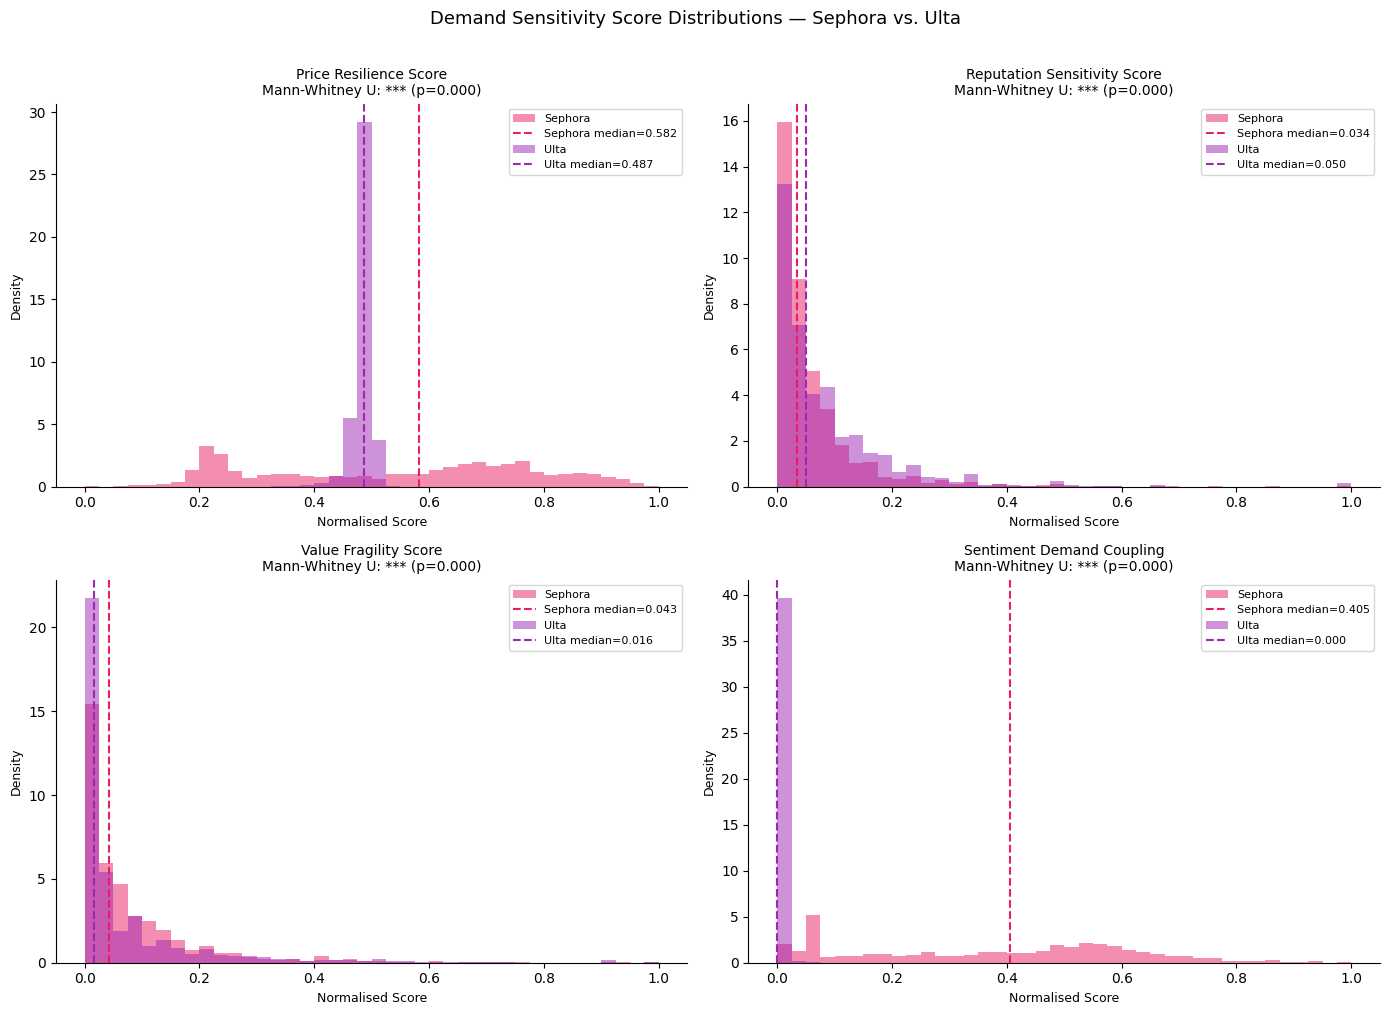

In [30]:
plot_sens = [c for c in ["price_resilience_score", "reputation_sensitivity_score",
                          "value_fragility_score", "sentiment_demand_coupling"]
             if c in all_feat.columns]

if plot_sens:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()

    for ax, col in zip(axes, plot_sens):
        for platform, color in [("Sephora", SEPHORA_COLOR), ("Ulta", ULTA_COLOR)]:
            sub = all_feat[all_feat["platform"] == platform][col].dropna()
            ax.hist(sub, bins=40, color=color, alpha=0.5,
                    label=platform, density=True, edgecolor="none")
            ax.axvline(sub.median(), color=color, lw=1.5, ls="--",
                       label=f"{platform} median={sub.median():.3f}")

        # Significance test
        s_vals = all_feat[all_feat["platform"] == "Sephora"][col].dropna()
        u_vals = all_feat[all_feat["platform"] == "Ulta"][col].dropna()
        if len(s_vals) > 5 and len(u_vals) > 5:
            t, p = stats.mannwhitneyu(s_vals, u_vals, alternative="two-sided")
            sig  = "***" if p < 0.001 else "**" if p < 0.01 else \
                   "*" if p < 0.05 else "ns"
            ax.set_title(f"{col.replace('_', ' ').title()}\n"
                         f"Mann-Whitney U: {sig} (p={p:.3f})",
                         fontsize=10)
        else:
            ax.set_title(col.replace("_", " ").title(), fontsize=10)

        ax.legend(fontsize=8)
        ax.set_xlabel("Normalised Score", fontsize=9)
        ax.set_ylabel("Density", fontsize=9)
        ax.spines[["top", "right"]].set_visible(False)

    fig.suptitle("Demand Sensitivity Score Distributions — Sephora vs. Ulta",
                 fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "3.2_sensitivity_distributions.png",
                dpi=150, bbox_inches="tight")
    plt.show()

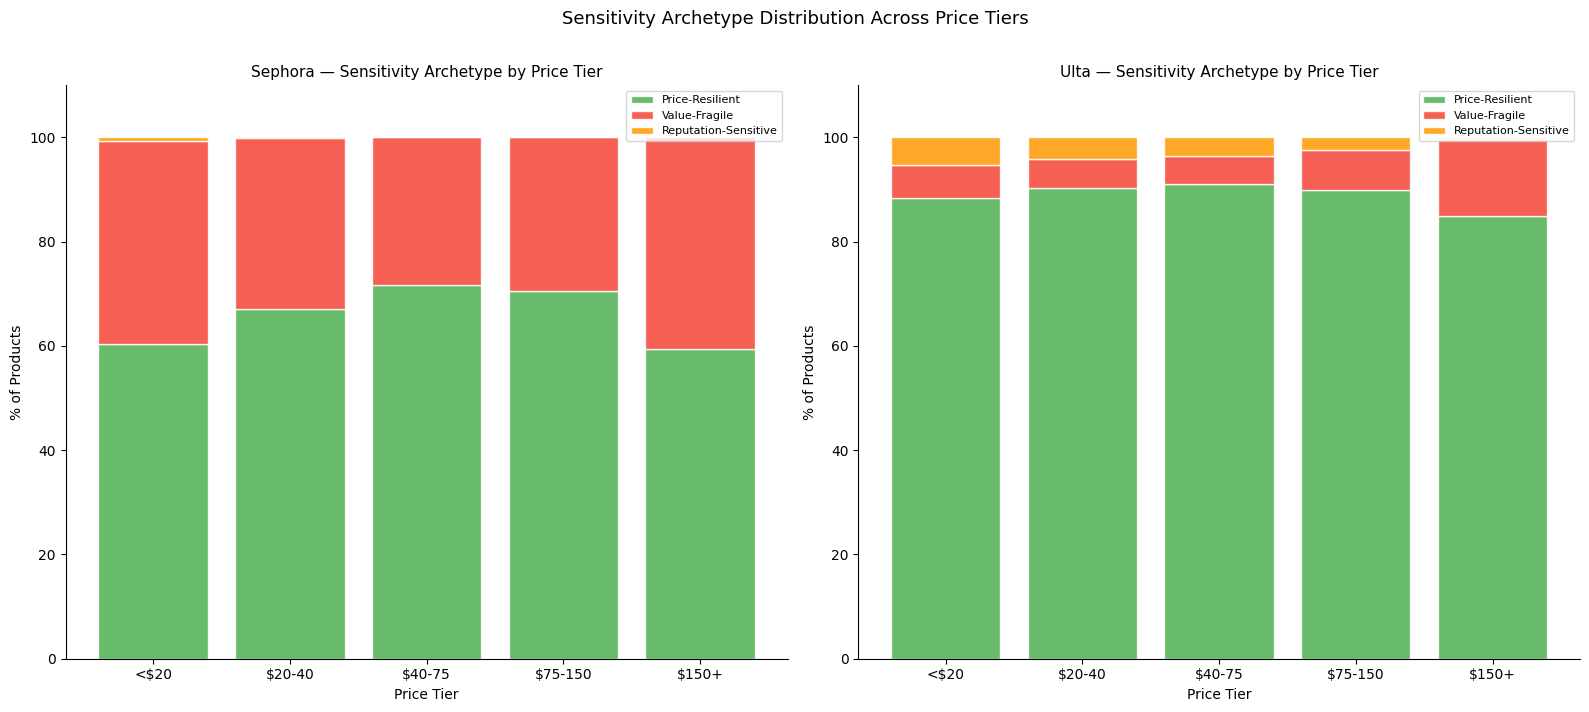

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Panel 1: stacked bar by platform × price tier
if "price_tier" in all_feat.columns:
    for ax, platform, color_base in [(axes[0], "Sephora", SEPHORA_COLOR),
                                      (axes[1], "Ulta",    ULTA_COLOR)]:
        sub      = all_feat[all_feat["platform"] == platform].dropna(subset=["price_tier"])
        ct       = sub.groupby(["price_tier", "archetype"]).size().unstack(fill_value=0)
        ct_pct   = ct.div(ct.sum(axis=1), axis=0) * 100

        bottom = np.zeros(len(ct_pct))
        for arch in ["Price-Resilient", "Value-Fragile", "Reputation-Sensitive"]:
            if arch in ct_pct.columns:
                ax.bar(ct_pct.index.astype(str), ct_pct[arch],
                       bottom=bottom, color=ARCH_COLORS[arch],
                       alpha=0.85, label=arch, edgecolor="white")
                bottom += ct_pct[arch].values

        ax.set_xlabel("Price Tier", fontsize=10)
        ax.set_ylabel("% of Products", fontsize=10)
        ax.set_title(f"{platform} — Sensitivity Archetype by Price Tier",
                     fontsize=11)
        ax.legend(fontsize=8, loc="upper right")
        ax.set_ylim(0, 110)
        ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("Sensitivity Archetype Distribution Across Price Tiers",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "3.2_archetype_by_price_tier.png",
            dpi=150, bbox_inches="tight")
plt.show()

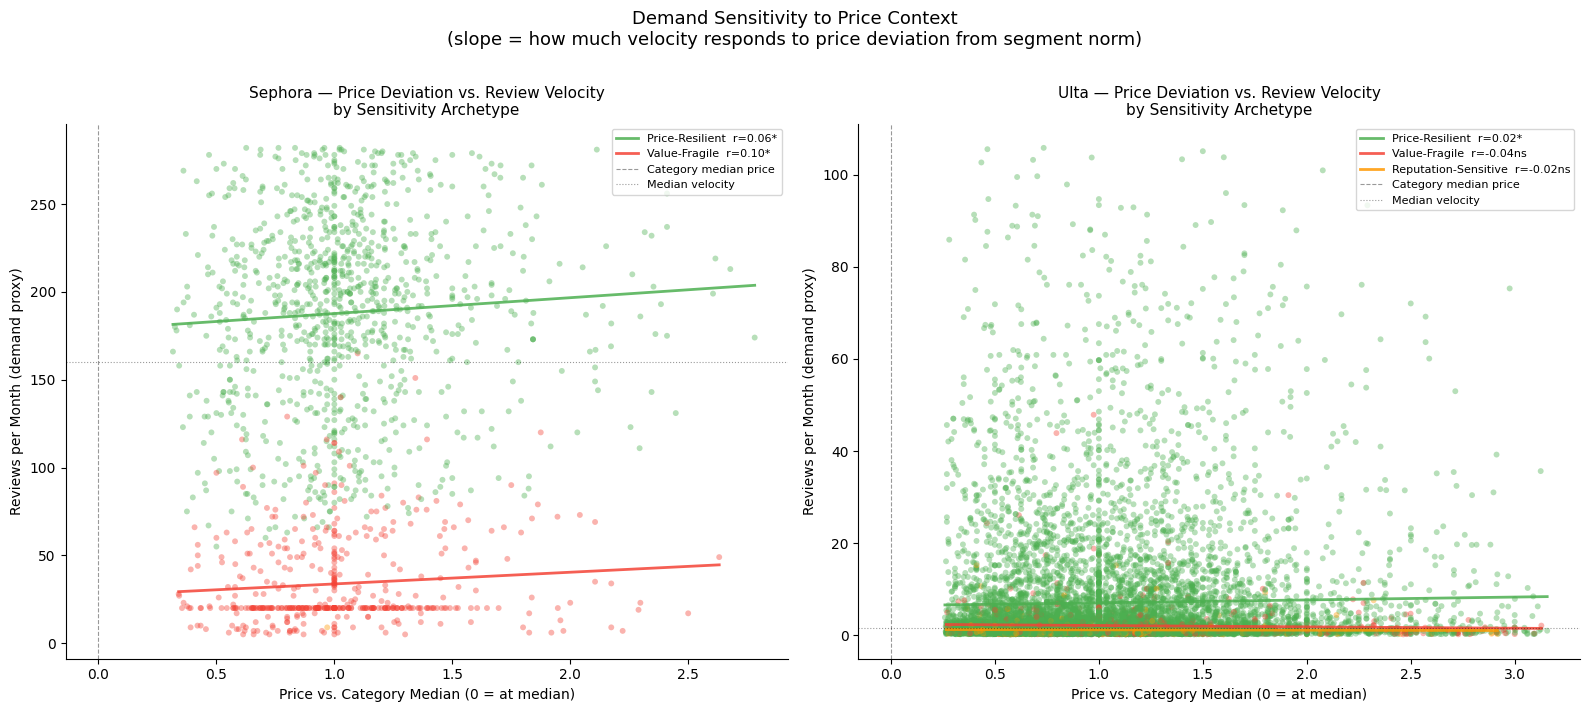

In [32]:
# Core demand sensitivity signal: does velocity hold up as price deviates from norm?

if "price_vs_category_median" in all_feat.columns and \
   "reviews_per_month" in all_feat.columns:

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    for ax, platform, color in [(axes[0], "Sephora", SEPHORA_COLOR),
                                  (axes[1], "Ulta",    ULTA_COLOR)]:
        sub = all_feat[
            (all_feat["platform"] == platform) &
            all_feat["price_vs_category_median"].notna() &
            all_feat["reviews_per_month"].notna()
        ].copy()

        # Clip extremes for readability
        sub = sub[
            sub["price_vs_category_median"].between(
                sub["price_vs_category_median"].quantile(0.02),
                sub["price_vs_category_median"].quantile(0.98)
            ) &
            sub["reviews_per_month"].between(
                sub["reviews_per_month"].quantile(0.02),
                sub["reviews_per_month"].quantile(0.98)
            )
        ]

        sc = ax.scatter(
            sub["price_vs_category_median"],
            sub["reviews_per_month"],
            c=[ARCH_COLORS[a] for a in sub["archetype"]],
            alpha=0.4, s=18, edgecolors="none",
        )

        # Regression line per archetype
        for arch in ["Price-Resilient", "Value-Fragile", "Reputation-Sensitive"]:
            asub = sub[sub["archetype"] == arch]
            if len(asub) > 20:
                m, b, r, p, _ = stats.linregress(
                    asub["price_vs_category_median"],
                    asub["reviews_per_month"]
                )
                xl = np.linspace(asub["price_vs_category_median"].min(),
                                 asub["price_vs_category_median"].max(), 100)
                sig = "***" if p < 0.001 else "**" if p < 0.01 else \
                      "*" if p < 0.05 else "ns"
                ax.plot(xl, m * xl + b,
                        color=ARCH_COLORS[arch], lw=2, alpha=0.85,
                        label=f"{arch}  r={r:.2f}{sig}")

        ax.axvline(0, color="black", lw=0.8, ls="--", alpha=0.4,
                   label="Category median price")
        ax.axhline(sub["reviews_per_month"].median(), color="black",
                   lw=0.8, ls=":", alpha=0.4, label="Median velocity")
        ax.set_xlabel("Price vs. Category Median (0 = at median)", fontsize=10)
        ax.set_ylabel("Reviews per Month (demand proxy)", fontsize=10)
        ax.set_title(f"{platform} — Price Deviation vs. Review Velocity\n"
                     f"by Sensitivity Archetype", fontsize=11)
        ax.legend(fontsize=8)
        ax.spines[["top", "right"]].set_visible(False)

    fig.suptitle("Demand Sensitivity to Price Context\n"
                 "(slope = how much velocity responds to price deviation from segment norm)",
                 fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "3.2_price_deviation_velocity.png",
                dpi=150, bbox_inches="tight")
    plt.show()

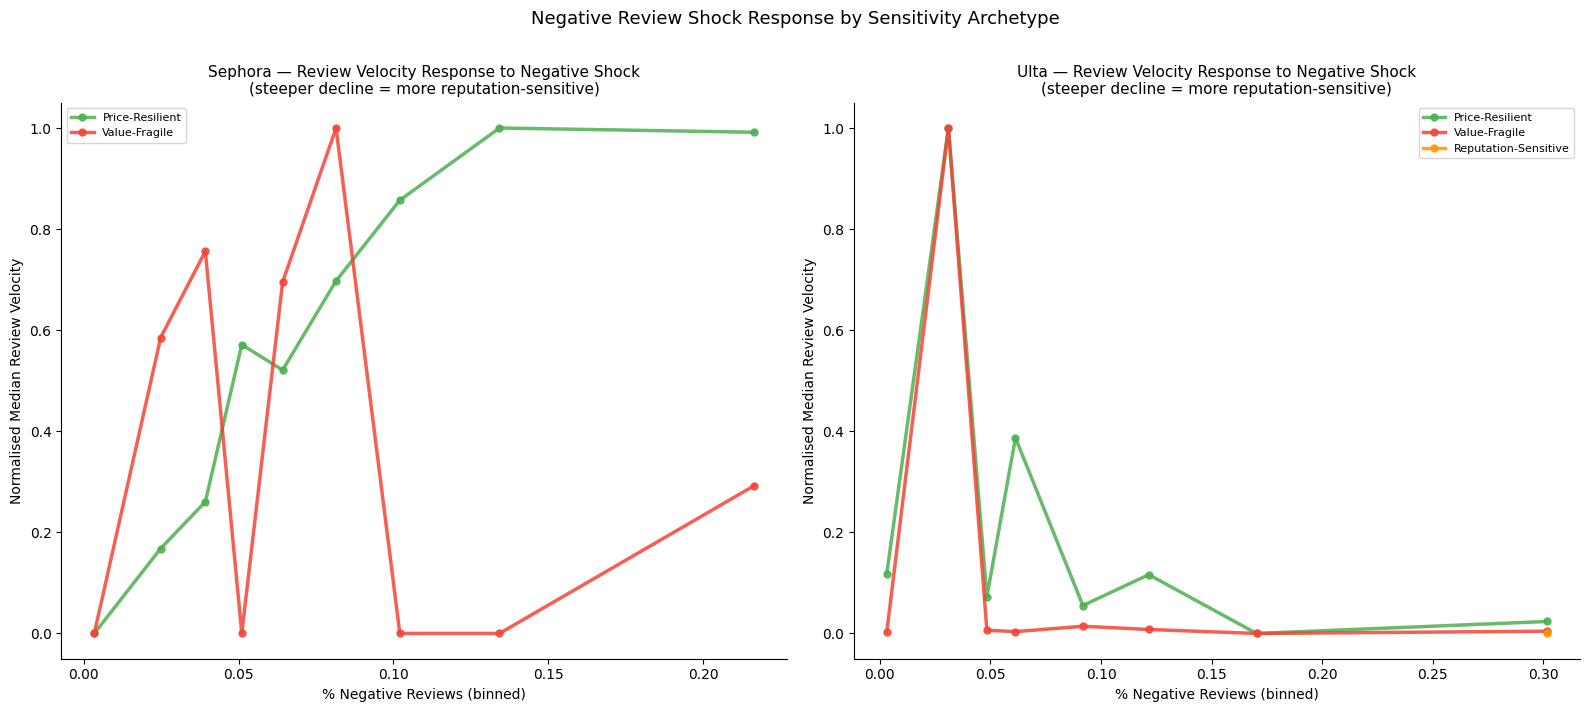

In [33]:
# For each archetype: how does review velocity relate to pct_negative?
# Resilient: velocity stable or rising despite high pct_negative
# Fragile: velocity drops as pct_negative rises

if "pct_negative" in all_feat.columns and "reviews_per_month" in all_feat.columns:
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    for ax, platform, color in [(axes[0], "Sephora", SEPHORA_COLOR),
                                  (axes[1], "Ulta",    ULTA_COLOR)]:
        sub = all_feat[
            (all_feat["platform"] == platform) &
            all_feat["pct_negative"].notna() &
            all_feat["reviews_per_month"].notna()
        ].copy()

        sub = sub[
            sub["pct_negative"].between(0, 0.5) &
            sub["reviews_per_month"].between(
                sub["reviews_per_month"].quantile(0.02),
                sub["reviews_per_month"].quantile(0.98)
            )
        ]

        # Bin pct_negative into deciles and compute median velocity per bin per archetype
        sub["neg_bin"] = pd.qcut(sub["pct_negative"], q=10, duplicates="drop")
        bin_mids = sub.groupby("neg_bin")["pct_negative"].mean()

        for arch in ["Price-Resilient", "Value-Fragile", "Reputation-Sensitive"]:
            asub = sub[sub["archetype"] == arch]
            if len(asub) < 10:
                continue
            grp = asub.groupby("neg_bin")["reviews_per_month"].median()
            # Normalise velocity to [0,1] for comparability
            grp_n = (grp - grp.min()) / (grp.max() - grp.min() + 1e-9)
            ax.plot(
                [bin_mids[b] for b in grp.index if b in bin_mids.index],
                [grp_n[b] for b in grp.index if b in bin_mids.index],
                color=ARCH_COLORS[arch], lw=2.5, marker="o",
                markersize=5, label=arch, alpha=0.85
            )

        ax.set_xlabel("% Negative Reviews (binned)", fontsize=10)
        ax.set_ylabel("Normalised Median Review Velocity", fontsize=10)
        ax.set_title(f"{platform} — Review Velocity Response to Negative Shock\n"
                     "(steeper decline = more reputation-sensitive)",
                     fontsize=11)
        ax.legend(fontsize=8)
        ax.spines[["top", "right"]].set_visible(False)

    fig.suptitle("Negative Review Shock Response by Sensitivity Archetype",
                 fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "3.2_shock_response.png",
                dpi=150, bbox_inches="tight")
    plt.show()

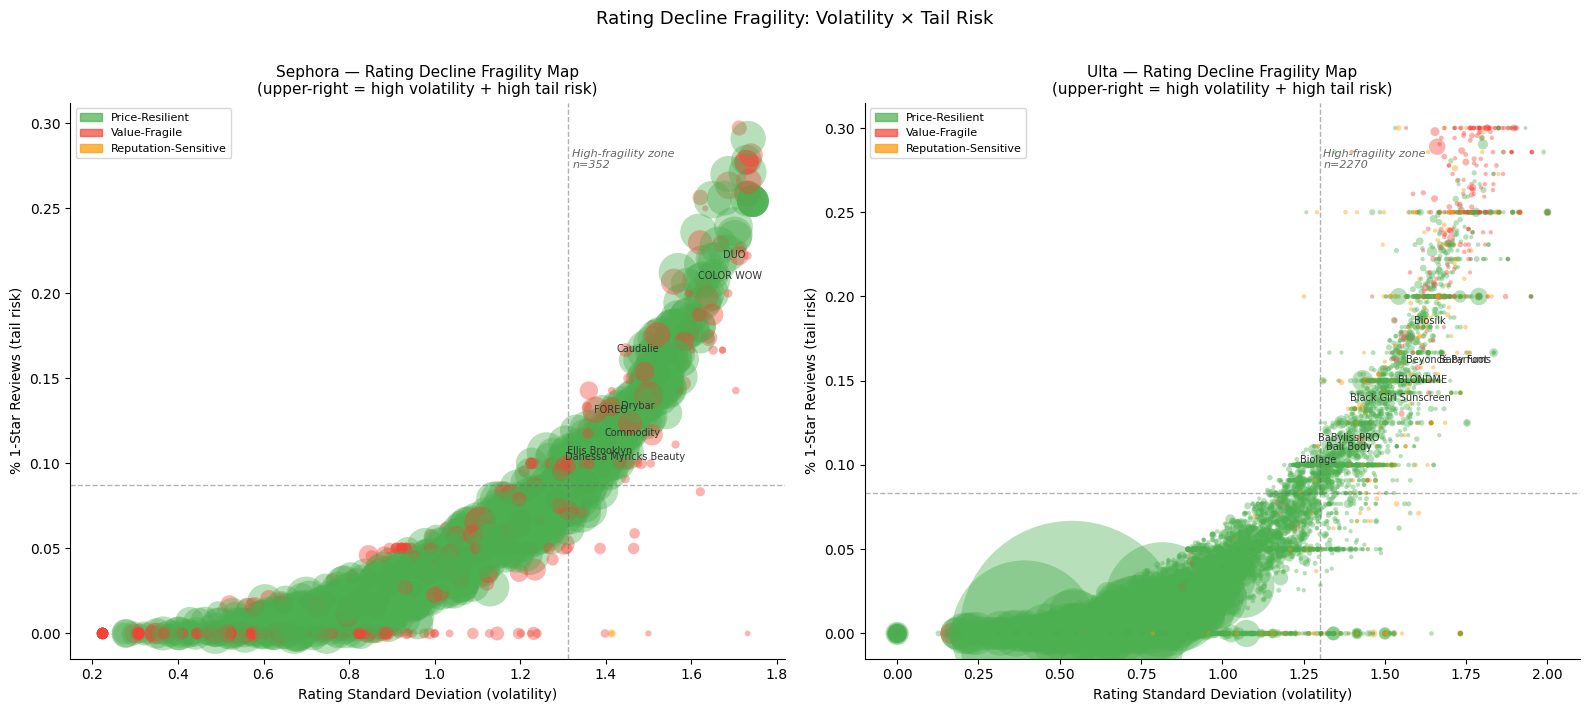

In [34]:
# Axes: rating_std (volatility) × pct_1_star (tail risk)
# Coloured by archetype; size = review velocity
# Brands in high-std, high-tail zone = most fragile to rating decline events

if "rating_std" in all_feat.columns and "pct_1_star" in all_feat.columns:
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    for ax, platform in [(axes[0], "Sephora"), (axes[1], "Ulta")]:
        sub = all_feat[
            (all_feat["platform"] == platform) &
            all_feat["rating_std"].notna() &
            all_feat["pct_1_star"].notna()
        ].copy()

        sub = sub[
            sub["rating_std"].between(
                sub["rating_std"].quantile(0.02),
                sub["rating_std"].quantile(0.98)
            ) &
            sub["pct_1_star"].between(0, 0.3)
        ]

        size_col = "reviews_per_month" if "reviews_per_month" in sub.columns else None
        sizes    = (sub[size_col] * 3 + 8) if size_col else 15

        ax.scatter(
            sub["rating_std"], sub["pct_1_star"],
            c=[ARCH_COLORS[a] for a in sub["archetype"]],
            s=sizes, alpha=0.4, edgecolors="none",
        )

        # Mark the high-fragility zone
        std_thr = sub["rating_std"].quantile(0.75)
        neg_thr = sub["pct_1_star"].quantile(0.75)
        ax.axvline(std_thr, color="#666", lw=1, ls="--", alpha=0.5)
        ax.axhline(neg_thr, color="#666", lw=1, ls="--", alpha=0.5)

        # Count fragile zone
        n_fragile = ((sub["rating_std"] > std_thr) &
                     (sub["pct_1_star"] > neg_thr)).sum()
        ax.text(std_thr + 0.01,
                sub["pct_1_star"].max() * 0.92,
                f"High-fragility zone\nn={n_fragile}",
                fontsize=8, color="#666", style="italic")

        # Brand-level aggregation overlay (means per brand)
        brand_agg = (sub.groupby("brand")
                     .agg(rs=("rating_std", "mean"),
                          p1=("pct_1_star", "mean"),
                          n=("brand", "count"),
                          arch=("archetype", lambda x: x.mode()[0]))
                     .reset_index())
        # Label top-fragility brands
        top_frag = brand_agg[
            (brand_agg["rs"] > brand_agg["rs"].quantile(0.85)) &
            (brand_agg["p1"] > brand_agg["p1"].quantile(0.85))
        ].head(8)
        for _, row in top_frag.iterrows():
            ax.annotate(row["brand"],
                        xy=(row["rs"], row["p1"]),
                        xytext=(4, 3), textcoords="offset points",
                        fontsize=7, color="#333",
                        arrowprops=dict(arrowstyle="-", color="#ccc", lw=0.4))

        ax.set_xlabel("Rating Standard Deviation (volatility)", fontsize=10)
        ax.set_ylabel("% 1-Star Reviews (tail risk)", fontsize=10)
        ax.set_title(f"{platform} — Rating Decline Fragility Map\n"
                     "(upper-right = high volatility + high tail risk)",
                     fontsize=11)

        legend_items = [mpatches.Patch(color=c, label=a, alpha=0.7)
                        for a, c in ARCH_COLORS.items()]
        ax.legend(handles=legend_items, fontsize=8)
        ax.spines[["top", "right"]].set_visible(False)

    fig.suptitle("Rating Decline Fragility: Volatility × Tail Risk",
                 fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "3.2_fragility_map.png",
                dpi=150, bbox_inches="tight")
    plt.show()

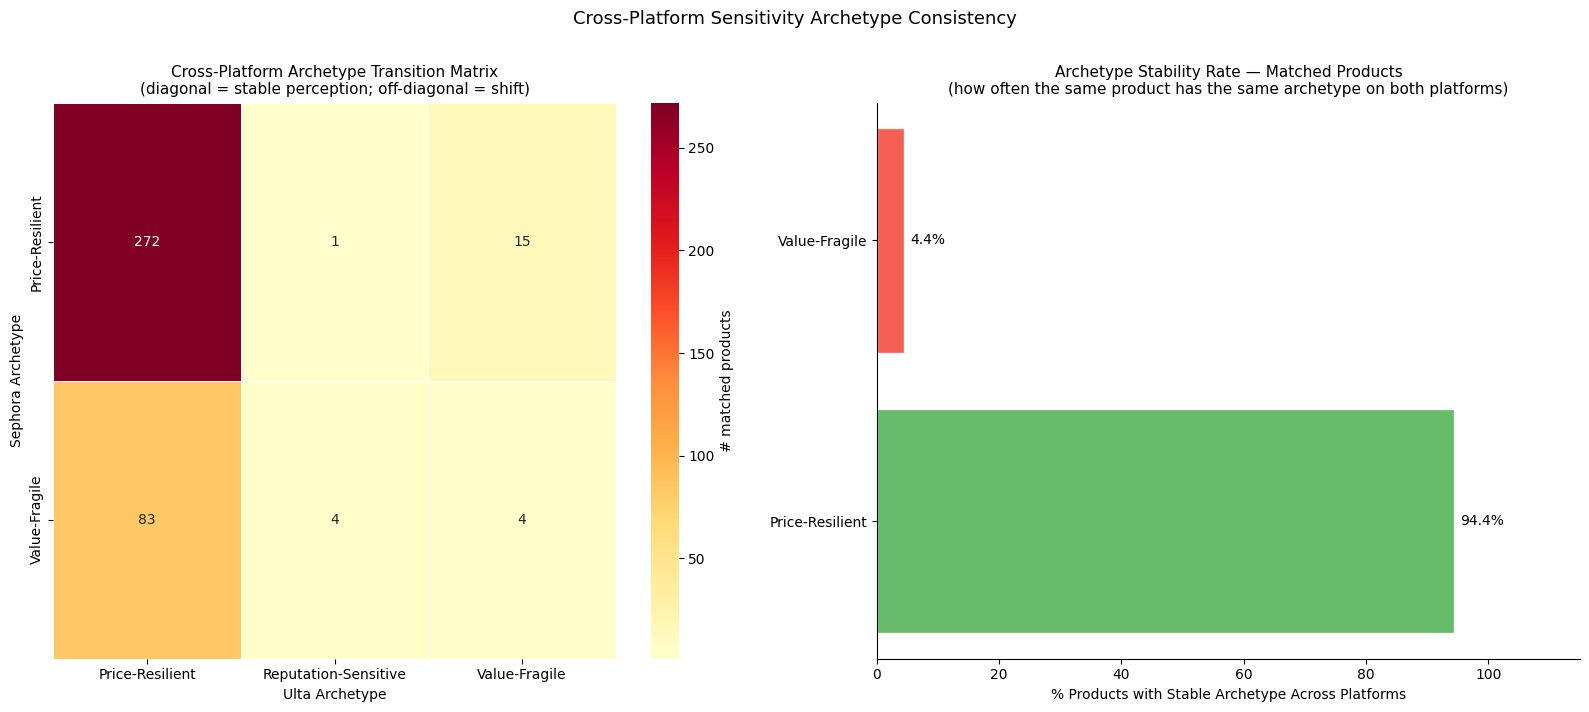

In [35]:
if len(matched) > 0:
    s_arch = (all_feat[all_feat["platform"] == "Sephora"]
              [["product_id", "archetype", "brand"]]
              .rename(columns={"archetype": "arch_s"}))
    u_arch = (all_feat[all_feat["platform"] == "Ulta"]
              [["product_id", "archetype", "brand"]]
              .rename(columns={"archetype": "arch_u"}))

    # Try to join on matched product IDs
    id_col_s = "sephora_product_id" if "sephora_product_id" in matched.columns \
               else "product_id_sephora"
    id_col_u = "ulta_product_id"    if "ulta_product_id"    in matched.columns \
               else "product_id_ulta"

    if id_col_s in matched.columns and id_col_u in matched.columns:
        pair_arch = (matched[[id_col_s, id_col_u]]
                     .merge(s_arch, left_on=id_col_s,
                            right_on="product_id", how="inner")
                     .merge(u_arch, left_on=id_col_u,
                            right_on="product_id", how="inner",
                            suffixes=("_s", "_u")))

        if len(pair_arch) > 0:
            # Sankey-style cross-tab
            ct = pd.crosstab(pair_arch["arch_s"], pair_arch["arch_u"])

            fig, axes = plt.subplots(1, 2, figsize=(16, 7))

            # Panel 1: heatmap of archetype transitions
            sns.heatmap(ct, ax=axes[0], annot=True, fmt="d",
                        cmap="YlOrRd", linewidths=0.5,
                        cbar_kws={"label": "# matched products"})
            axes[0].set_xlabel("Ulta Archetype",    fontsize=10)
            axes[0].set_ylabel("Sephora Archetype", fontsize=10)
            axes[0].set_title("Cross-Platform Archetype Transition Matrix\n"
                              "(diagonal = stable perception; off-diagonal = shift)",
                              fontsize=11)

            # Panel 2: stability rate by archetype
            arch_list = ["Price-Resilient", "Value-Fragile", "Reputation-Sensitive"]
            stability = {}
            for arch in arch_list:
                if arch in ct.index and arch in ct.columns:
                    total = ct.loc[arch].sum()
                    same  = ct.loc[arch, arch] if arch in ct.columns else 0
                    stability[arch] = same / total if total > 0 else 0

            if stability:
                bars = axes[1].barh(
                    list(stability.keys()),
                    [v * 100 for v in stability.values()],
                    color=[ARCH_COLORS[a] for a in stability.keys()],
                    alpha=0.85, edgecolor="white"
                )
                for bar, (arch, val) in zip(bars, stability.items()):
                    axes[1].text(bar.get_width() + 1,
                                 bar.get_y() + bar.get_height() / 2,
                                 f"{val:.1%}", va="center", fontsize=10)

                axes[1].set_xlabel("% Products with Stable Archetype Across Platforms",
                                   fontsize=10)
                axes[1].set_title("Archetype Stability Rate — Matched Products\n"
                                  "(how often the same product has the same archetype "
                                  "on both platforms)",
                                  fontsize=11)
                axes[1].set_xlim(0, 115)
                axes[1].spines[["top", "right"]].set_visible(False)

            fig.suptitle("Cross-Platform Sensitivity Archetype Consistency",
                         fontsize=13, y=1.01)
            plt.tight_layout()
            plt.savefig(OUTPUT_DIR / "3.2_crossplatform_archetype.png",
                        dpi=150, bbox_inches="tight")
            plt.show()

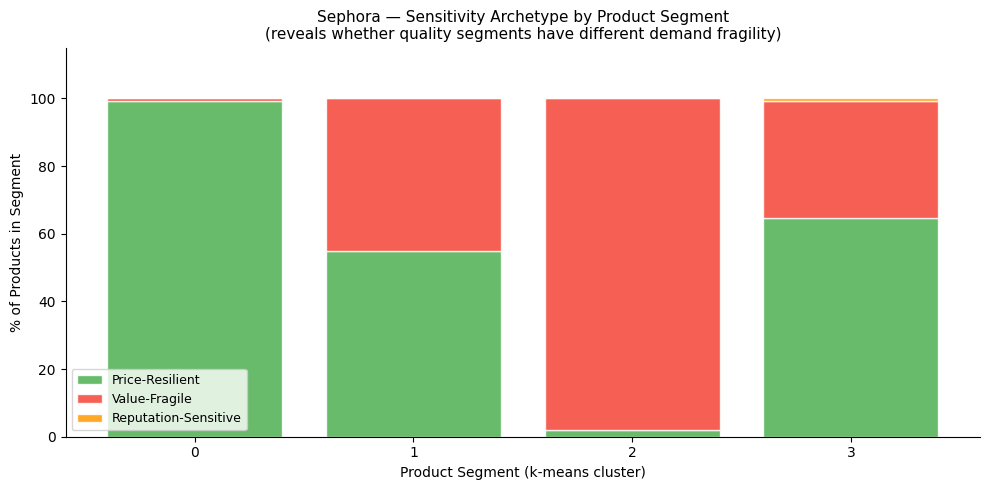

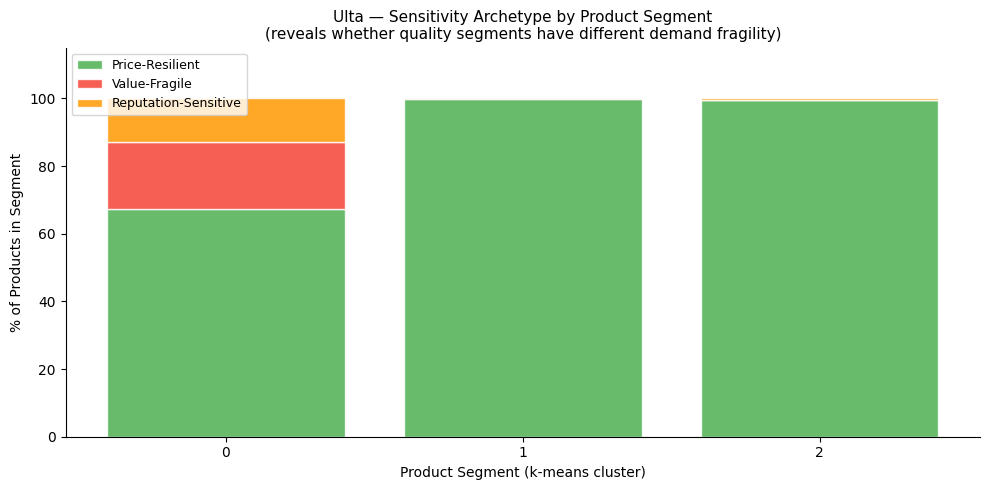

In [36]:
# Aggregate archetype distribution by product cluster (kmeans_weighted)
# Reveals whether certain quality segments are structurally more resilient

for platform, df_seg, color in [
    ("Sephora", s_feat, SEPHORA_COLOR),
    ("Ulta",    u_feat, ULTA_COLOR),
]:
    if "kmeans_weighted" not in df_seg.columns:
        continue

    seg_feat = df_seg.copy()
    seg_feat["platform"] = platform
    seg_feat = all_feat[all_feat["platform"] == platform].copy()

    if "kmeans_weighted" not in seg_feat.columns:
        continue

    ct = pd.crosstab(seg_feat["kmeans_weighted"], seg_feat["archetype"],
                     normalize="index") * 100

    fig, ax = plt.subplots(figsize=(10, 5))
    bottom = np.zeros(len(ct))
    for arch in ["Price-Resilient", "Value-Fragile", "Reputation-Sensitive"]:
        if arch in ct.columns:
            ax.bar(ct.index.astype(str), ct[arch], bottom=bottom,
                   color=ARCH_COLORS[arch], alpha=0.85,
                   label=arch, edgecolor="white")
            bottom += ct[arch].values

    ax.set_xlabel("Product Segment (k-means cluster)", fontsize=10)
    ax.set_ylabel("% of Products in Segment", fontsize=10)
    ax.set_title(f"{platform} — Sensitivity Archetype by Product Segment\n"
                 "(reveals whether quality segments have different demand fragility)",
                 fontsize=11)
    ax.legend(fontsize=9)
    ax.set_ylim(0, 115)
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"3.2_segment_sensitivity_{platform.lower()}.png",
                dpi=150, bbox_inches="tight")
    plt.show()

In [38]:
print("  3.2  DEMAND SENSITIVITY — SUMMARY")

print(f"\nSensitivity dimensions: {', '.join(SENS_COLS)}")

for platform in ["Sephora", "Ulta"]:
    sub = all_feat[all_feat["platform"] == platform]
    print(f"\n{'─'*40}")
    print(f"  {platform}  (n={len(sub):,} products)")
    print(f"{'─'*40}")

    arch_counts = sub["archetype"].value_counts()
    for arch, cnt in arch_counts.items():
        print(f"  {arch:<25} {cnt:>5}  ({cnt/len(sub):.1%})")

    for arch in ["Price-Resilient", "Value-Fragile", "Reputation-Sensitive"]:
        asub = sub[sub["archetype"] == arch]
        if len(asub) == 0:
            continue
        print(f"\n  {arch} — top 5 brands:")
        brand_col = "brand" if "brand" in asub.columns else "brand_normalized"
        if brand_col in asub.columns and "reviews_per_month" in asub.columns:
            top = (asub.groupby(brand_col)["reviews_per_month"].mean()
                   .sort_values(ascending=False).head(5))
            for brand, vel in top.items():
                print(f"    {brand:<35} velocity={vel:.1f}")

    # Key sensitivity stats
    if "price_vs_category_median" in sub.columns and \
       "reviews_per_month" in sub.columns:
        r, p = stats.pearsonr(
            sub["price_vs_category_median"].fillna(0),
            sub["reviews_per_month"].fillna(0)
        )
        sig  = "***" if p < 0.001 else "**" if p < 0.01 else \
               "*" if p < 0.05 else "ns"
        print(f"\n  Price deviation × velocity correlation: r={r:.3f} {sig}")

    if "pct_negative" in sub.columns and "reviews_per_month" in sub.columns:
        r, p = stats.pearsonr(
            sub["pct_negative"].fillna(0),
            sub["reviews_per_month"].fillna(0)
        )
        sig  = "***" if p < 0.001 else "**" if p < 0.01 else \
               "*" if p < 0.05 else "ns"
        print(f"  Negative review % × velocity correlation: r={r:.3f} {sig}")

  3.2  DEMAND SENSITIVITY — SUMMARY

Sensitivity dimensions: price_resilience_score, price_sensitivity_score, reputation_sensitivity_score, controversy_resilience_score, value_fragility_score, sentiment_demand_coupling

────────────────────────────────────────
  Sephora  (n=1,632 products)
────────────────────────────────────────
  Price-Resilient            1099  (67.3%)
  Value-Fragile               531  (32.5%)
  Reputation-Sensitive          2  (0.1%)

  Price-Resilient — top 5 brands:
    KORRES                              velocity=287.0
    Mizani                              velocity=272.7
    DUO                                 velocity=270.0
    PAT McGRATH LABS                    velocity=268.4
    Cinema Secrets                      velocity=263.5

  Value-Fragile — top 5 brands:
    SK-II                               velocity=213.0
    HUDA BEAUTY                         velocity=165.0
    Living Proof                        velocity=151.0
    Farmacy                     

## 3.2 Perceived Value, Price Context and Demand Sensitivity

### Archetype Composition and Platform Character

The two platforms produce structurally different demand sensitivity landscapes. Sephora classifies 67.3% of its 1,632 products as Price-Resilient and 32.5% as Value-Fragile, a meaningful minority indicating that roughly one in three Sephora products carries measurable fragility risk — velocity that depends on sustained positive quality signals rather than price position alone. Ulta presents a far more resilient catalog at the product level: 89.4% of 11,227 products are Price-Resilient, with Value-Fragile products constituting only 6.3%. The Reputation-Sensitive archetype is nearly absent on Sephora (0.1%, just two products) but represents 4.2% of Ulta's catalog — a meaningful 477 products whose review velocity is directly suppressed by negative review accumulation. This asymmetry reflects the compositional differences established in section 3.1: Ulta's mass catalog is structurally dominated by high-volume, low-variance commodity products that are largely indifferent to price deviation, while Sephora's prestige catalog contains a substantial cohort of products whose demand is contingent on maintained quality perception.

### Sensitivity Score Distributions

All four sensitivity dimensions show statistically significant platform differences (Mann-Whitney p < 0.001 across the board), confirming that the distributional gap is not sampling noise. The price resilience score distributions show the clearest structural divergence: Sephora's distribution is wide and right-skewed with a median of 0.582, while Ulta's spikes sharply at 0.487 with very little variance — almost the entire Ulta catalog is clustered at a single resilience level, reflecting the homogeneity of its mass product composition. Sephora's wider spread means some products are genuinely highly resilient and others are genuinely fragile, whereas Ulta products are uniformly moderate.

The sentiment-demand coupling chart reveals perhaps the most strategically significant platform difference. Sephora's median coupling score is 0.405 — meaning the typical Sephora product sits in a regime where sentiment meaningfully co-moves with review velocity, and demand for these products is partly sentiment-driven. Ulta's median coupling is exactly 0.000, with a density spike at zero so extreme it dwarfs the rest of the distribution. The practical implication is that on Ulta, sentiment and demand largely decouple: products generate reviews at their own baseline velocity regardless of whether those reviews are positive or negative. On Sephora, sentiment is a demand signal. This distinction has direct consequences for how brands should respond to negative review events on each platform — on Sephora, a negative sentiment shift is a leading indicator of velocity decline; on Ulta, it typically is not.

### Price Deviation and Velocity Response

The price deviation scatter confirms that Price-Resilient products on Sephora maintain substantially higher baseline velocity regardless of where they sit relative to the category median price — the green cloud sits uniformly above the red cloud across the entire price deviation range, with Price-Resilient brands averaging around 180 reviews per month versus roughly 30 for Value-Fragile brands. Both archetypes show weakly positive slopes (r = 0.06 and r = 0.10, both significant at p < 0.05), meaning products priced above their category median actually attract slightly more review activity on Sephora, not less. This is consistent with the prestige premium dynamics identified in section 3.2: on Sephora, pricing above the category norm is a quality signal that drives engagement rather than a deterrent.

On Ulta the picture collapses. Correlations for all three archetypes are near zero and non-significant, and the entire catalog operates at velocity levels so compressed — nearly all products below 20 reviews per month — that price deviation has no measurable effect on demand. The green dominance of the Ulta scatter reflects the archetype composition: there are simply very few Value-Fragile or Reputation-Sensitive products visible in the cloud. For Ulta, price deviation from the category median is not a demand-relevant variable.

### Negative Review Shock Response

The shock response trajectories are noisier than the other charts due to small bin counts at high negative-review-rate percentiles, but the directional pattern on Sephora is interpretable. The Value-Fragile archetype shows a characteristic spike-and-collapse pattern: velocity peaks briefly at moderate negative review rates (around 8–9%) before dropping sharply to near zero at 10%, then partially recovering. This is consistent with a controversy-engagement dynamic followed by abandonment — negative reviews initially drive traffic as consumers investigate the controversy, then velocity collapses once the reputational damage accumulates past a threshold. The Price-Resilient archetype on Sephora shows a steadier upward trajectory, with velocity actually rising as negative review rates increase — these are products generating sufficient positive engagement to absorb negative reviews without velocity loss, likely high-traction brands where controversy coexists with loyal demand.

On Ulta, both archetypes converge to near-zero velocity above 5% negative reviews, with no meaningful differentiation between Price-Resilient and Value-Fragile trajectories beyond the first two bins. This confirms the Ulta decoupling observed in the sentiment coupling chart: archetype classification does not predict shock response behavior on Ulta the way it does on Sephora, because the velocity signal itself is too compressed and too heterogeneous to carry a clear archetype-differentiated pattern.

### Rating Decline Fragility

The fragility maps expose a structural difference in where risk concentrates. Sephora's high-fragility zone (n=352, upper-right quadrant) is populated predominantly by Price-Resilient products — green dominates even at high volatility and high tail risk. The brands labeled in this zone — DUO, COLOR WOW, Caudalie, FOREO, Brybar — are all high-velocity prestige or tool brands that generate enough review volume to accumulate 1-star tail events even while maintaining strong average ratings. Their presence in the fragility zone is more a function of product volume and consumer diversity than structural quality weakness. The Value-Fragile products on Sephora cluster tightly in the moderate-volatility, low-tail-risk zone (ratings std around 0.8–1.2, pct_1star below 5%), suggesting that Value-Fragile classification on Sephora is driven more by velocity suppression relative to price deviation than by actual rating instability.

Ulta's fragility map is dramatically different in scale: 2,270 products in the high-fragility zone versus 352 on Sephora, reflecting the much larger catalog size. The labeled brands — Biosilk, BLONDME, Black Girl Sunscreen, BaBylissPRO, Biolage — are mid-market haircare and tool brands whose Ulta reviewer bases generate high 1-star rates alongside high volatility, consistent with the polarizing-but-high-volume quadrant identified in the perceptual maps. Notably, the Ulta fragility zone contains a much larger proportion of red and orange points (Value-Fragile and Reputation-Sensitive archetypes) concentrated at the extreme right edge of the volatility axis, confirming that these archetypes, while small in number, cluster precisely in the highest-risk zone of the catalog.

### Cross-Platform Archetype Stability

The transition matrix provides the most direct answer to whether demand sensitivity is a product-level property or a channel-level property. Price-Resilient products on Sephora show 94.4% archetype stability on Ulta — 272 of 288 Price-Resilient Sephora products retain the same classification when sold at Ulta. Value-Fragile products, however, show only 4.4% stability: of 91 Value-Fragile Sephora products, 83 reclassify as Price-Resilient on Ulta and only 4 remain Value-Fragile. This is a striking finding. It means that value fragility on Sephora is not an intrinsic product property but a channel-conditional one: the same product that shows fragile, sentiment-contingent demand on Sephora becomes resilient when placed in Ulta's environment. The most plausible mechanism is that Ulta's larger, more heterogeneous consumer base dilutes the concentrated quality-signaling community that makes Sephora demand sensitive to sentiment shifts. A product surrounded by Sephora's curation and prestige floor effect is vulnerable to reputational dynamics; the same product in Ulta's mass-market context generates demand through different mechanisms — availability, price accessibility, brand familiarity — that are not sensitive to the same quality-perception signals.

### Segment-Level Sensitivity Patterns

The segment charts reveal that demand fragility on Sephora is strongly segment-differentiated in a non-monotonic pattern. Segment 0 is nearly entirely Price-Resilient (98%), forming the stable foundation of Sephora's catalog — likely the high-efficacy, low-divisiveness prestige core identified in section 2.2. Segments 1 and 2 flip dramatically, with Value-Fragile products constituting approximately 45% and 97% of each respectively, identifying two distinct product groups whose demand is contingent on sustained sentiment performance. Segment 3 returns to mixed composition (65% Price-Resilient, 35% Value-Fragile), suggesting a moderate-fragility tier. On Ulta, the segment structure is simpler: Segment 0 contains the only meaningful Value-Fragile and Reputation-Sensitive presence (~20% and ~15% respectively), while Segments 1 and 2 are almost entirely Price-Resilient. Segment 0 at Ulta represents the highest-risk concentration in that catalog — a specific product cluster where demand is unusually sensitive relative to the Ulta baseline, and where the reputation-sensitive archetype appears at its only meaningful scale in the entire platform.